# Milan Mobile Traffic Forecasting — Part 2: Exploratory Analysis

Reads the compact Parquet artefacts written by **01_data_pipeline.ipynb** and characterises the
data's spatial, temporal and statistical structure.

Every analysis here exists to justify a modelling decision in notebook 3, so each is read for what
it implies about the forecasting problem rather than as a description of the data.

**Runtime:** CPU is fine.

In [1]:
!pip -q install pyarrow statsmodels

import os, json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/milan_traffic_project"
FIG_DIR = os.path.join(DRIVE_PROJECT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "semibold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=PALETTE)

def save(fig, name):
    p = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(p); print("saved:", p)

Mounted at /content/drive


## Load the compact dataset

In [2]:
totals = pd.read_parquet(os.path.join(DRIVE_PROJECT_DIR, "totals_by_square.parquet"))
areas_df = pd.read_parquet(os.path.join(DRIVE_PROJECT_DIR, "areas_of_interest.parquet"))
meta = json.load(open(os.path.join(DRIVE_PROJECT_DIR, "meta.json")))

TOP3 = meta["top3"]
REFERENCE_SQUARES = meta["reference"]
AREAS = meta["areas"]
SLOTS_PER_DAY, WEEK = 144, 1008

def series(square_id):
    """Full two-month series for one area, indexed by local time."""
    s = areas_df[areas_df.SquareId == square_id].set_index("Timestamp")["Internet"]
    return s.astype("float64").sort_index()

print(f"totals    : {len(totals):,} areas")
print(f"areas_df  : {len(areas_df):,} rows for areas {AREAS}")
print(f"time span : {areas_df.Timestamp.min()}  ->  {areas_df.Timestamp.max()}")
print(f"intervals : {areas_df.Timestamp.nunique():,}")

totals    : 10,000 areas
areas_df  : 44,640 rows for areas [5161, 5059, 5259, 4159, 4556]
time span : 2013-11-01 00:00:00+01:00  ->  2014-01-01 23:50:00+01:00
intervals : 8,928


## 1. Distribution of total Internet traffic across areas

saved: /content/drive/MyDrive/milan_traffic_project/figures/task2_1_traffic_distribution.png


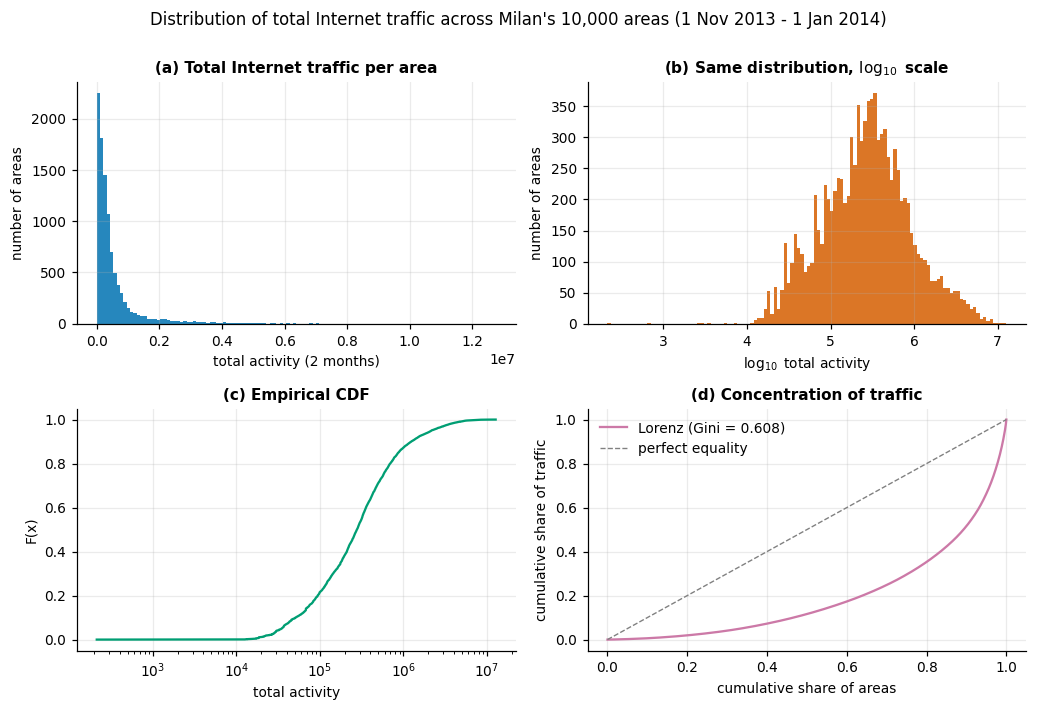

,statistic,value
0,areas,1.000000e+04
1,mean,5.552894e+05
2,median,2.778711e+05
3,std,8.925511e+05
4,min,2.136265e+02
5,max,1.274006e+07
6,max/median,4.584881e+01
7,skewness,4.265382e+00
8,kurtosis,2.551556e+01
9,Gini,6.080796e-01


In [3]:
v = totals["TotalInternet"].to_numpy()
pos = v[v > 0]

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4))

axes[0,0].hist(v, bins=120, color=PALETTE[0], alpha=0.85)
axes[0,0].set(title="(a) Total Internet traffic per area",
              xlabel="total activity (2 months)", ylabel="number of areas")

axes[0,1].hist(np.log10(pos), bins=120, color=PALETTE[1], alpha=0.85)
axes[0,1].set(title="(b) Same distribution, $\\log_{10}$ scale",
              xlabel="$\\log_{10}$ total activity", ylabel="number of areas")

s_sorted = np.sort(v)
axes[1,0].plot(s_sorted, np.arange(1, len(s_sorted)+1)/len(s_sorted), color=PALETTE[2])
axes[1,0].set(title="(c) Empirical CDF", xlabel="total activity", ylabel="F(x)", xscale="log")

share = np.cumsum(s_sorted) / s_sorted.sum()
frac = np.arange(1, len(s_sorted)+1) / len(s_sorted)
trapz = getattr(np, "trapezoid", np.trapz)
gini = float(1 - 2*trapz(share, frac))
axes[1,1].plot(frac, share, color=PALETTE[3], label=f"Lorenz (Gini = {gini:.3f})")
axes[1,1].plot([0,1], [0,1], ls="--", lw=0.9, color="grey", label="perfect equality")
axes[1,1].set(title="(d) Concentration of traffic",
              xlabel="cumulative share of areas", ylabel="cumulative share of traffic")
axes[1,1].legend(loc="upper left")

fig.suptitle("Distribution of total Internet traffic across Milan's 10,000 areas "
             "(1 Nov 2013 - 1 Jan 2014)", y=1.0)
fig.tight_layout(); save(fig, "task2_1_traffic_distribution"); plt.show()

summary = pd.DataFrame({"statistic": [
    "areas","mean","median","std","min","max","max/median","skewness","kurtosis",
    "Gini","share held by busiest 1%","share held by busiest 10%","skewness of log10(x)"],
  "value": [len(v), v.mean(), np.median(v), v.std(), v.min(), v.max(),
            v.max()/np.median(v), pd.Series(v).skew(), pd.Series(v).kurt(), gini,
            s_sorted[-len(s_sorted)//100:].sum()/s_sorted.sum(),
            s_sorted[-len(s_sorted)//10:].sum()/s_sorted.sum(),
            pd.Series(np.log10(pos)).skew()]})
summary

**Discussion.** Total Internet traffic spans four orders of magnitude, with a maximum-to-median
ratio around 46 and raw skewness above 4. The informative panel is (b): on a log scale the skewness
collapses to roughly **0.02**, which is as close to symmetric as an empirical distribution of 10,000
observations realistically gets. The distribution is therefore approximately **log-normal** — the
standard signature of urban activity measures, arising when many multiplicative factors
(population density, land use, transport access) compound.

The Lorenz curve gives a Gini around **0.61**: the busiest 1% of areas carry roughly 11% of all
traffic and the busiest 10% carry nearly half.

**Why this matters for forecasting.** Because levels differ by orders of magnitude, absolute error
metrics are *not comparable across areas* — an RMSE of 120 is unremarkable in an area averaging
1,400 activity units and impossible in one averaging 20. Notebook 3 therefore reports a scale-free
skill score alongside MAE and RMSE, and compares model *rankings* across areas rather than raw
errors.

### Where the traffic is

saved: /content/drive/MyDrive/milan_traffic_project/figures/task2_1_spatial_map.png


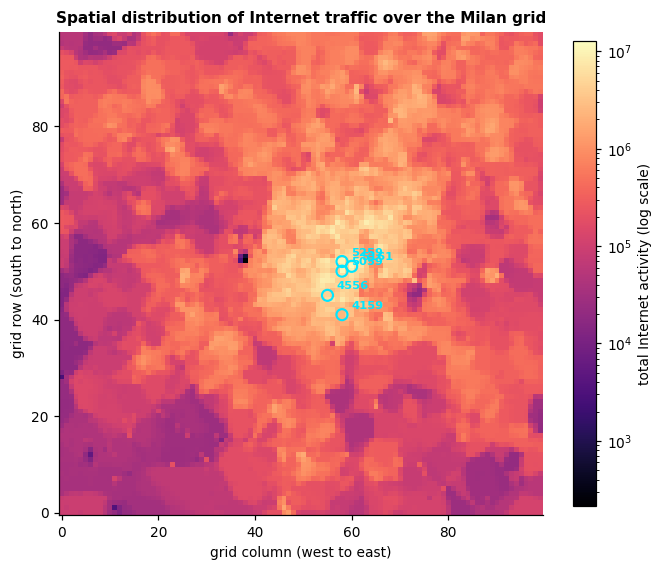

,square_id,row,col,total,rank,percentile
0,5161,51,60,12740060.0,1,100.00
1,5059,50,58,11170854.0,2,99.99
2,5259,52,58,10485780.0,3,99.98
3,4159,41,58,2454134.5,424,95.77
4,4556,45,55,4574671.5,109,98.92


In [4]:
grid = totals.sort_values("SquareId")["TotalInternet"].to_numpy().reshape(100, 100)

fig, ax = plt.subplots(figsize=(6.2, 5.6))
im = ax.imshow(grid, origin="lower", cmap="magma",
               norm=LogNorm(vmin=max(grid[grid>0].min(), 1), vmax=grid.max()))
fig.colorbar(im, ax=ax, shrink=0.82, label="total Internet activity (log scale)")
for sq in AREAS:
    r, c = (sq-1)//100, (sq-1)%100
    ax.scatter([c],[r], s=52, facecolors="none", edgecolors="#00E5FF", linewidths=1.4)
    ax.annotate(str(sq), (c,r), textcoords="offset points", xytext=(6,4),
                color="#00E5FF", fontsize=7.5, weight="bold")
ax.set(title="Spatial distribution of Internet traffic over the Milan grid",
       xlabel="grid column (west to east)", ylabel="grid row (south to north)")
ax.grid(False)
fig.tight_layout(); save(fig, "task2_1_spatial_map"); plt.show()

rows = []
for sq in AREAS:
    t = totals.loc[totals.SquareId == sq, "TotalInternet"].iloc[0]
    rows.append({"square_id": sq, "row": (sq-1)//100, "col": (sq-1)%100, "total": t,
                 "rank": int((totals.TotalInternet > t).sum()+1),
                 "percentile": round(float((totals.TotalInternet <= t).mean()*100), 2)})
pd.DataFrame(rows)

**Discussion.** High traffic is contiguous, not scattered: the three busiest squares occupy adjacent
cells near grid rows 50–52, columns 57–60 — the geographic centre of the city. The two reference
areas named in the brief sit well outside that core, in the upper few percent by rank but with a
fifth to a third of the busiest area's volume. They are evidently chosen as deliberate contrasts,
which is what makes the cross-area question in notebook 3 answerable.

## 2. The five areas of interest over the first two weeks

saved: /content/drive/MyDrive/milan_traffic_project/figures/task2_2_first_two_weeks.png


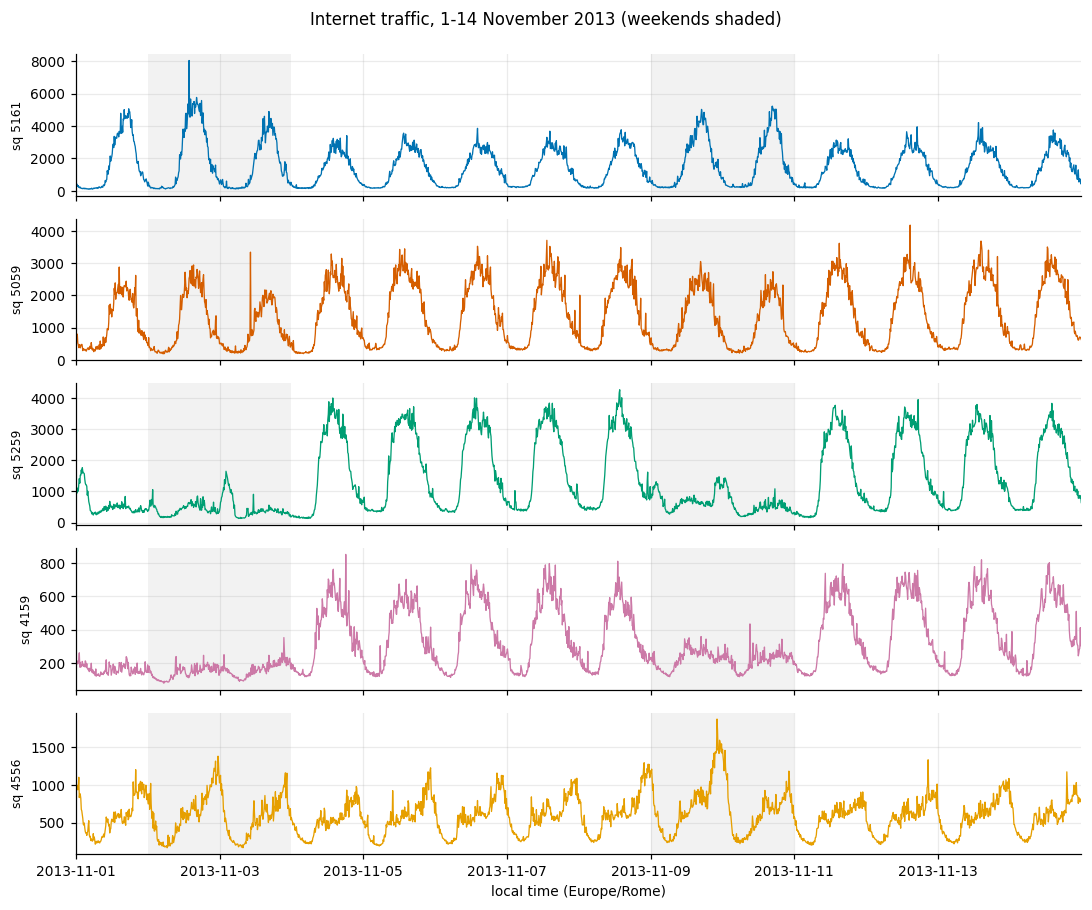

In [5]:
idx = np.sort(areas_df.Timestamp.unique())[:2*WEEK]
idx = pd.DatetimeIndex(idx)

fig, axes = plt.subplots(len(AREAS), 1, figsize=(10, 1.65*len(AREAS)), sharex=True)
for ax, sq, colour in zip(np.atleast_1d(axes), AREAS, PALETTE):
    s = series(sq).iloc[:2*WEEK]
    ax.plot(idx, s.to_numpy(), color=colour, lw=0.85)
    ax.set_ylabel(f"sq {sq}", fontsize=8); ax.margins(x=0)
    for day in pd.date_range(idx[0].normalize(), idx[-1], freq="D"):
        if day.dayofweek >= 5:
            ax.axvspan(day, day+pd.Timedelta(days=1), color="grey", alpha=0.10, lw=0)
np.atleast_1d(axes)[-1].set_xlabel("local time (Europe/Rome)")
fig.suptitle("Internet traffic, 1-14 November 2013 (weekends shaded)", y=0.995)
fig.tight_layout(); save(fig, "task2_2_first_two_weeks"); plt.show()

In [6]:
from statsmodels.tsa.stattools import acf

stats = []
for sq in AREAS:
    s = series(sq)
    by_hour = s.groupby(s.index.hour).mean()
    wd, we = s[s.index.dayofweek < 5], s[s.index.dayofweek >= 5]
    a = acf(s, nlags=WEEK, fft=True)
    stats.append({"square_id": sq, "total": s.sum(), "mean": s.mean(), "std": s.std(),
                  "cv": s.std()/s.mean(),
                  "peak_to_trough": by_hour.max()/by_hour.min(),
                  "peak_hour": int(by_hour.idxmax()), "trough_hour": int(by_hour.idxmin()),
                  "weekend_weekday_ratio": we.mean()/wd.mean(),
                  "acf_lag1": a[1], "acf_daily_144": a[SLOTS_PER_DAY], "acf_weekly_1008": a[WEEK]})
shape_stats = pd.DataFrame(stats)
shape_stats.round(4)

,square_id,total,mean,std,cv,peak_to_trough,peak_hour,trough_hour,weekend_weekday_ratio,acf_lag1,acf_daily_144,acf_weekly_1008
0,5161,1.274006e+07,1426.9781,1381.6492,0.9682,19.6834,16,4,1.3843,0.9871,0.8783,0.8377
1,5059,1.117085e+07,1251.2158,961.4722,0.7684,9.0931,14,4,0.8610,0.9800,0.8993,0.8169
2,5259,1.048578e+07,1174.4825,1102.8251,0.9390,7.7228,13,6,0.4254,0.9916,0.6952,0.7559
3,4159,2.454134e+06,274.8807,181.3288,0.6597,3.6865,12,5,0.5870,0.9760,0.7770,0.7661
4,4556,4.574671e+06,512.3960,248.2672,0.4845,3.8099,22,5,1.1401,0.9582,0.8079,0.7369


**Discussion.** The five areas differ in *shape*, not merely in level — which is what makes the
cross-area comparison meaningful. Four behavioural signatures emerge, each consistent with a
plausible land use:

- **Square 5161** has the most extreme daily cycle and is the only area where **weekends are busier
  than weekdays**. A late-afternoon peak plus weekend amplification is a leisure/tourist signature,
  consistent with its position at the exact centre of the city.
- **Squares 5259 and 4159** show the opposite: weekend traffic drops sharply, with midday peaks.
  These behave as office areas that empty when work stops. Square 5259 is the more extreme case
  despite ranking third by volume, showing that volume and regularity are independent properties.
- **Square 4556** is the clearest contrast — the flattest profile in the set, the latest peak by a
  wide margin (around 22:00), and slightly elevated weekend traffic. A late-evening peak with low
  volatility is residential: demand arrives when people are home. It also has the *lowest* lag-1
  autocorrelation, i.e. it is the noisiest series relative to its own scale.

**The number that matters most:** lag-1 autocorrelation exceeds 0.95 in every area. At a ten-minute
resolution the most recent observation is already an excellent predictor, so every model in
notebook 3 must be judged against a persistence baseline rather than against zero.

## 3. Two additional analyses on the highest-traffic area

In [7]:
FOCUS = TOP3[0]
s = series(FOCUS)
print(f"Analysing square {FOCUS}: {len(s):,} intervals, "
      f"mean {s.mean():.1f}, std {s.std():.1f}")

Analysing square 5161: 8,928 intervals, mean 1427.0, std 1381.6


### Analysis 1 — multi-seasonal decomposition (MSTL)

Plain STL assumes a single period. Mobile traffic carries at least two — a daily commute/sleep cycle
and a weekday/weekend cycle — so MSTL is the honest tool here. A single-period decomposition would
push the weekly component into the remainder and **overstate how much of the signal is
unpredictable**, which would lead to a materially wrong conclusion about what a forecaster can
achieve.

saved: /content/drive/MyDrive/milan_traffic_project/figures/task2_3_decomposition_sq5161.png


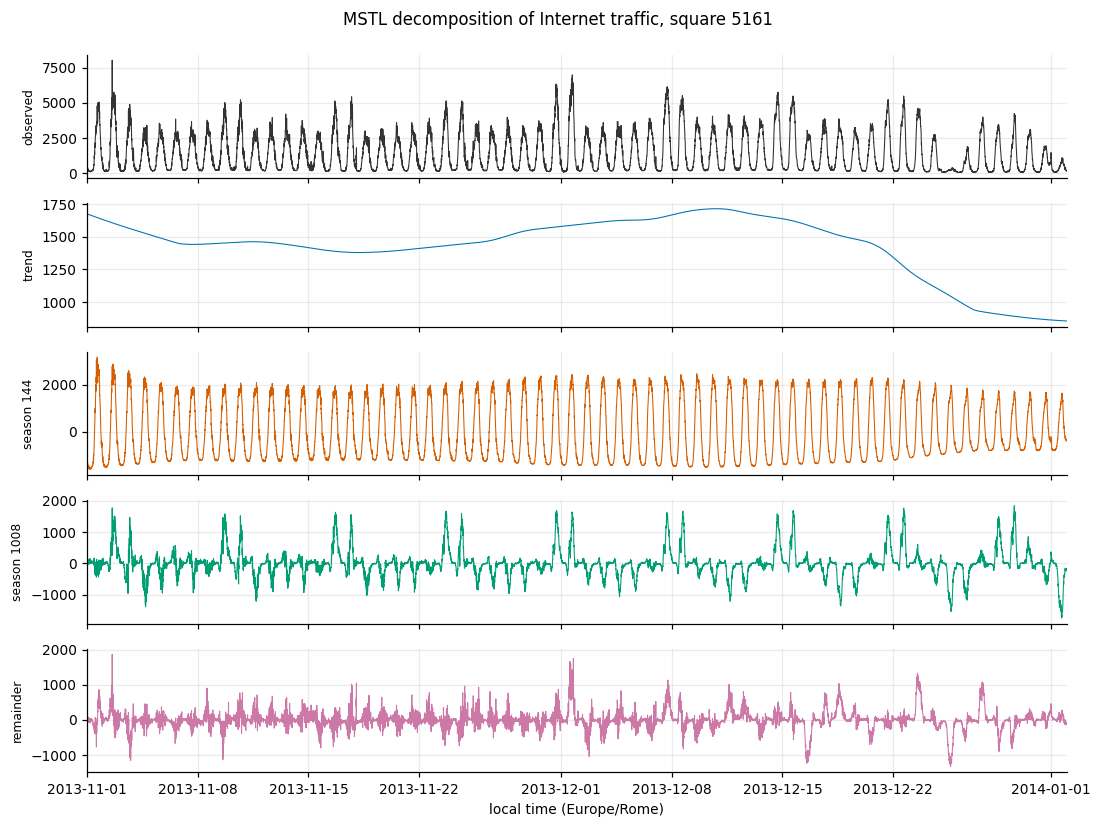

Daily seasonal strength F_S = 0.9585   (1 = pure seasonality)


,component,variance,share_of_total_variance
2,seasonal_144,1.583045e+06,0.8294
3,seasonal_1008,1.905895e+05,0.0999
1,remainder,6.876212e+04,0.0360
0,trend,5.265057e+04,0.0276


In [8]:
from statsmodels.tsa.seasonal import MSTL

res = MSTL(s, periods=(SLOTS_PER_DAY, WEEK)).fit()

components = {"trend": res.trend, "remainder": res.resid}
seasonal = res.seasonal
if isinstance(seasonal, pd.DataFrame):
    for col in seasonal.columns:
        components[col] = seasonal[col]
else:
    components["seasonal"] = seasonal

order = ["observed", "trend"] + [k for k in components if k.startswith("seasonal")] + ["remainder"]
series_map = {"observed": s, **components}

fig, axes = plt.subplots(len(order), 1, figsize=(10, 1.5*len(order)), sharex=True)
for ax, key, colour in zip(axes, order, ["#333333"] + PALETTE):
    ax.plot(s.index, np.asarray(series_map[key]), color=colour, lw=0.7)
    ax.set_ylabel(key.replace("seasonal_", "season "), fontsize=8); ax.margins(x=0)
axes[-1].set_xlabel("local time (Europe/Rome)")
fig.suptitle(f"MSTL decomposition of Internet traffic, square {FOCUS}", y=0.995)
fig.tight_layout(); save(fig, f"task2_3_decomposition_sq{FOCUS}"); plt.show()

total_var = float(np.var(s))
tab = pd.DataFrame([{"component": k, "variance": float(np.var(v)),
                     "share_of_total_variance": float(np.var(v)/total_var)}
                    for k, v in components.items()]).sort_values(
                    "share_of_total_variance", ascending=False)

# Hyndman's seasonal strength: F_S = max(0, 1 - Var(resid) / Var(resid + seasonal))
comp = seasonal.iloc[:, 0] if isinstance(seasonal, pd.DataFrame) else seasonal
resid = np.asarray(res.resid)
F_S = max(0.0, 1 - np.var(resid)/np.var(resid + np.asarray(comp)))
print(f"Daily seasonal strength F_S = {F_S:.4f}   (1 = pure seasonality)")
tab.round(4)

**Discussion.** The variance partition is unambiguous: the daily cycle accounts for the large
majority, the weekly cycle roughly a tenth, and the remainder only a few percent.

Together these say something specific and consequential — **the overwhelming majority of the
variance is calendar-driven, and only a small fraction is genuinely stochastic**. A model that
captures the daily and weekly cycles has, in a variance-accounting sense, captured almost
everything, and the room available to a more expressive model is correspondingly narrow. This sets
the expectation that the three models in notebook 3 will finish close together, and that the
interesting comparison will be cost and robustness rather than headline accuracy.

### Analysis 2 — autocorrelation structure

The lags that matter for model design are 1 (persistence), 144 (same time yesterday) and 1008 (same
time last week). Their heights set the floor any learned model must beat and suggest the input
window length.

saved: /content/drive/MyDrive/milan_traffic_project/figures/task2_3_autocorrelation_sq5161.png


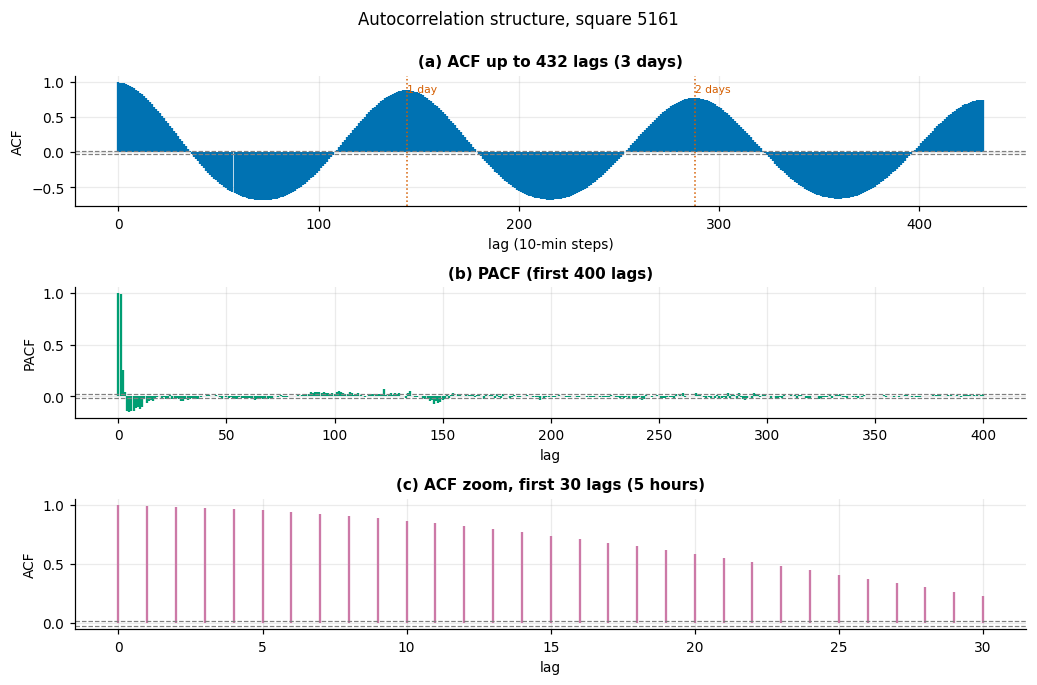

,lag,lag_label,acf,significant
0,1,10 min,0.9871,True
1,2,20 min,0.9810,True
2,3,30 min,0.9744,True
3,6,1 h,0.9388,True
4,18,3 h,0.6470,True
5,36,6 h,0.0099,False
6,72,12 h,-0.6832,True
7,144,1 d,0.8783,True
8,288,2 d,0.7696,True


In [9]:
from statsmodels.tsa.stattools import pacf

nlags = 3*SLOTS_PER_DAY
a = acf(s, nlags=nlags, fft=True)
p = pacf(s, nlags=400, method="ywm")
ci = 1.96/np.sqrt(len(s))

fig, axes = plt.subplots(3, 1, figsize=(9.5, 6.2))
axes[0].stem(np.arange(len(a)), a, markerfmt=" ", basefmt=" ", linefmt=PALETTE[0])
for lag, lbl in [(SLOTS_PER_DAY, "1 day"), (2*SLOTS_PER_DAY, "2 days")]:
    axes[0].axvline(lag, color=PALETTE[1], ls=":", lw=1.0)
    axes[0].annotate(lbl, (lag, a.max()*0.85), fontsize=7, color=PALETTE[1])
axes[0].set(title=f"(a) ACF up to {nlags} lags (3 days)", xlabel="lag (10-min steps)", ylabel="ACF")

axes[1].stem(np.arange(len(p)), p, markerfmt=" ", basefmt=" ", linefmt=PALETTE[2])
axes[1].set(title="(b) PACF (first 400 lags)", xlabel="lag", ylabel="PACF")

axes[2].stem(np.arange(31), a[:31], markerfmt=" ", basefmt=" ", linefmt=PALETTE[3])
axes[2].set(title="(c) ACF zoom, first 30 lags (5 hours)", xlabel="lag", ylabel="ACF")
for ax in axes:
    ax.axhline(ci, ls="--", lw=0.8, color="grey"); ax.axhline(-ci, ls="--", lw=0.8, color="grey")
fig.suptitle(f"Autocorrelation structure, square {FOCUS}", y=0.995)
fig.tight_layout(); save(fig, f"task2_3_autocorrelation_sq{FOCUS}"); plt.show()

def lag_label(k):
    m = k*10
    return f"{m} min" if m < 60 else (f"{m/60:.0f} h" if m < 1440 else f"{m/1440:.0f} d")

pd.DataFrame([{"lag": k, "lag_label": lag_label(k), "acf": float(a[k]),
               "significant": bool(abs(a[k]) > ci)}
              for k in [1,2,3,6,18,36,72,SLOTS_PER_DAY,2*SLOTS_PER_DAY] if k < len(a)]).round(4)

**Discussion.** The structure is textbook and has three consequences for model design.

1. **ACF at lag 1 is around 0.99.** Persistence sets an extremely high bar. This is why notebook 3
   reports naive baselines throughout rather than treating them as a formality.
2. **The series decorrelates completely at about six hours**, becomes strongly *anti*-correlated at
   twelve hours, and returns to a high value at exactly one day — confirming the daily period and
   justifying a seasonal specification in the statistical model.
3. **Significant correlation persists at one day and one week**, suggesting an input window covering
   a full day may be worth its cost. Notebook 3 tests this directly, and — as it turns out — the two
   neural architectures answer it differently.

### Supporting: stationarity

/tmp/ipykernel_3045/1124849339.py:14: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p = adfuller(v, autolag="AIC")[:2]
/tmp/ipykernel_3045/1124849339.py:15: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_stat, kpss_p = kpss(v, regression="c", nlags="auto")[:2]
/tmp/ipykernel_3045/1124849339.py:14: FutureWarning: adf

saved: /content/drive/MyDrive/milan_traffic_project/figures/task2_3_stationarity_sq5161.png


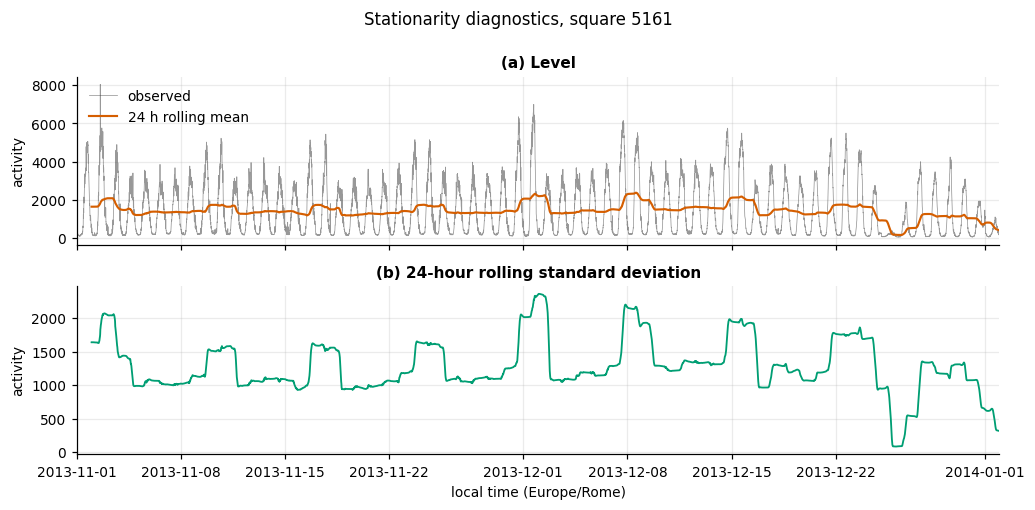

,series,ADF_stat,ADF_p,ADF_stationary,KPSS_stat,KPSS_p,KPSS_stationary,std
0,raw,-19.0319,0.0,True,0.2367,0.1,True,1381.5718
1,first difference,-15.1604,0.0,True,0.0033,0.1,True,221.1599
2,seasonal difference (lag 144),-11.8330,0.0,True,0.0694,0.1,True,639.0505
3,first + seasonal difference,-20.3140,0.0,True,0.0044,0.1,True,300.5751


In [10]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore", message=".*p-value is greater than.*")
warnings.filterwarnings("ignore", message=".*outside of the range of p-values.*")

variants = {
    "raw": s,
    "first difference": s.diff().dropna(),
    "seasonal difference (lag 144)": s.diff(SLOTS_PER_DAY).dropna(),
    "first + seasonal difference": s.diff().diff(SLOTS_PER_DAY).dropna(),
}
rows = []
for name, v in variants.items():
    adf_stat, adf_p = adfuller(v, autolag="AIC")[:2]
    kpss_stat, kpss_p = kpss(v, regression="c", nlags="auto")[:2]
    rows.append({"series": name, "ADF_stat": adf_stat, "ADF_p": adf_p,
                 "ADF_stationary": adf_p < 0.05, "KPSS_stat": kpss_stat, "KPSS_p": kpss_p,
                 "KPSS_stationary": kpss_p > 0.05, "std": float(np.std(v))})

roll_mean, roll_std = s.rolling(SLOTS_PER_DAY).mean(), s.rolling(SLOTS_PER_DAY).std()
fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.6), sharex=True)
axes[0].plot(s.index, s.to_numpy(), color="#333333", lw=0.5, alpha=0.5, label="observed")
axes[0].plot(roll_mean.index, roll_mean.to_numpy(), color=PALETTE[1], lw=1.4, label="24 h rolling mean")
axes[0].legend(loc="upper left"); axes[0].set(title="(a) Level", ylabel="activity")
axes[1].plot(roll_std.index, roll_std.to_numpy(), color=PALETTE[2], lw=1.2)
axes[1].set(title="(b) 24-hour rolling standard deviation", ylabel="activity",
            xlabel="local time (Europe/Rome)")
for ax in axes: ax.margins(x=0)
fig.suptitle(f"Stationarity diagnostics, square {FOCUS}", y=0.995)
fig.tight_layout(); save(fig, f"task2_3_stationarity_sq{FOCUS}"); plt.show()

pd.DataFrame(rows).round(4)

**Discussion.** The two tests have opposite null hypotheses, so agreement is meaningful. Here they
agree across every differencing scheme, including the raw series: ADF rejects a unit root and KPSS
fails to reject stationarity. (KPSS p-values are clipped to its lookup table — a reported `0.1`
means "greater than 0.1", not "equal to".)

More useful than the verdicts is the **standard deviation column**. First differencing reduces the
spread far more than seasonal differencing does, meaning consecutive observations are much more
alike than observations one day apart. That ordering predicts something testable: seasonal
differencing, which inflates innovation variance by combining two noisy observations, should
underperform a *harmonic* treatment of seasonality. Notebook 3 tests exactly this.

### Supporting: anomaly screening

saved: /content/drive/MyDrive/milan_traffic_project/figures/task2_3_anomalies_sq5161.png


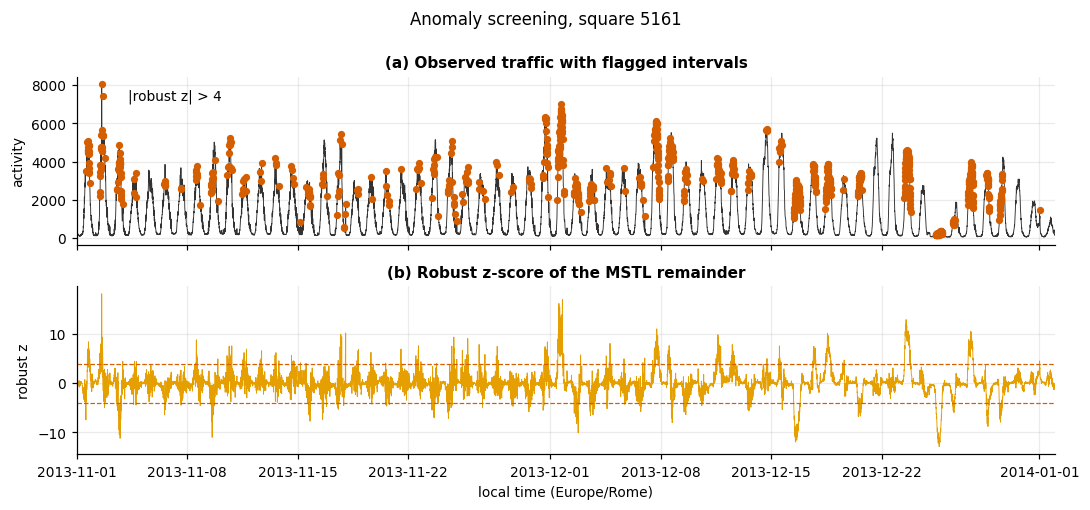

flagged 891 intervals (9.98% of the series)

Most-flagged dates, with the SIGN of the deviation:
  2013-12-16 (Mon):  59 flagged  (+0 above fit / -59 below fit)
  2013-12-23 (Mon):  57 flagged  (+57 above fit / -0 below fit)
  2013-12-25 (Wed):  57 flagged  (+0 above fit / -57 below fit)
  2013-12-27 (Fri):  50 flagged  (+50 above fit / -0 below fit)
  2013-12-01 (Sun):  49 flagged  (+49 above fit / -0 below fit)
  2013-12-18 (Wed):  49 flagged  (+49 above fit / -0 below fit)
  2013-12-07 (Sat):  42 flagged  (+42 above fit / -0 below fit)
  2013-12-11 (Wed):  30 flagged  (+30 above fit / -0 below fit)

Most unusual days by VOLUME (ratio to the median of the same weekday):
      date       total  vs_same_weekday
2013-12-25  26,313.557            0.135
2014-01-01  57,387.487            0.295
2013-12-26  76,244.041            0.393
2013-12-31 109,419.655            0.576
2013-12-28 166,112.503            0.662
2013-12-01 318,288.458            1.330

The evaluation week (16-22 Dec) in con

In [11]:
resid = pd.Series(np.asarray(res.resid), index=s.index)
med = resid.median(); mad = (resid - med).abs().median()
scale = 1.4826*mad if mad > 0 else resid.std()
z = (resid - med)/scale
flag = z[z.abs() > 4.0]

fig, axes = plt.subplots(2, 1, figsize=(10, 4.6), sharex=True)
axes[0].plot(s.index, s.to_numpy(), color="#333333", lw=0.6)
axes[0].scatter(flag.index, s.loc[flag.index].to_numpy(), s=14, color=PALETTE[1],
                zorder=3, label="|robust z| > 4")
axes[0].legend(loc="upper left"); axes[0].set(title="(a) Observed traffic with flagged intervals",
                                              ylabel="activity")
axes[1].plot(z.index, z.to_numpy(), color=PALETTE[4], lw=0.6)
axes[1].axhline(4, ls="--", lw=0.8, color=PALETTE[1]); axes[1].axhline(-4, ls="--", lw=0.8, color=PALETTE[1])
axes[1].set(title="(b) Robust z-score of the MSTL remainder", ylabel="robust z",
            xlabel="local time (Europe/Rome)")
for ax in axes: ax.margins(x=0)
fig.suptitle(f"Anomaly screening, square {FOCUS}", y=0.995)
fig.tight_layout(); save(fig, f"task2_3_anomalies_sq{FOCUS}"); plt.show()

print(f"flagged {len(flag)} intervals ({len(flag)/len(s)*100:.2f}% of the series)\n")
by_day = flag.groupby(flag.index.floor("D"))
print("Most-flagged dates, with the SIGN of the deviation:")
for d, grp in sorted(by_day, key=lambda kv: -len(kv[1]))[:8]:
    print(f"  {d.date()} ({d.day_name()[:3]}): {len(grp):3d} flagged  "
          f"(+{(grp>0).sum()} above fit / -{(grp<0).sum()} below fit)")

daily = s.groupby(s.index.floor("D")).sum()
dd = pd.DataFrame({"total": daily, "dow": daily.index.dayofweek})
dd["vs_same_weekday"] = dd["total"] / dd["dow"].map(dd.groupby("dow")["total"].median())
print("\nMost unusual days by VOLUME (ratio to the median of the same weekday):")
print(dd.assign(date=[i.date() for i in dd.index])[["date","total","vs_same_weekday"]]
        .reindex(dd.vs_same_weekday.sub(1).abs().sort_values(ascending=False).index)
        .head(6).to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

print("\nThe evaluation week (16-22 Dec) in context:")
print(dd.loc["2013-12-16":"2013-12-22"].assign(date=[i.date() for i in dd.loc['2013-12-16':'2013-12-22'].index])
        [["date","total","vs_same_weekday"]].to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

trend = pd.Series(np.asarray(res.trend), index=s.index).groupby(s.index.floor("D")).mean()
print(f"\nMSTL trend, 9 Dec -> 27 Dec: {trend.loc['2013-12-09']:.0f} -> {trend.loc['2013-12-27']:.0f} "
      f"({(trend.loc['2013-12-27']/trend.loc['2013-12-09']-1)*100:.0f}%)")

**Discussion — the single most consequential finding for the forecasting experiments.**

Two distinct notions of "anomalous" must be kept apart here, and conflating them is easy.

By **volume**, the extreme days are Christmas Day and New Year's Day, which fall to a small fraction
of a typical same-weekday total. The evaluation week, 16–22 December, is by contrast unremarkable —
its daily totals sit close to 1.0× the same weekday elsewhere in the series.

By **deviation from the fitted seasonal pattern**, 16 December is the most-flagged day in the whole
series, and every one of its flags is *below* the fit, concentrated in daytime hours. So the week is
normal in total volume but its intraday shape departs from the model's expectation.

Underlying both is the trend: it falls roughly 45% between 9 and 27 December as the city winds down
for Christmas. **The evaluation week sits on the leading edge of that decline, and the training data
ends on 15 December.** Every model in notebook 3 is therefore asked to forecast a period whose
downward drift it has never observed. That is the honest explanation for a large class of the errors
seen there, and it is revisited in the failure analysis.

## Summary — what the EDA decided

1. Traffic across areas is approximately log-normal with high concentration, so **absolute errors
   are not comparable across areas** — report a scale-free skill score.
2. The five areas differ in shape (leisure / office / residential), which makes the cross-area
   research question answerable rather than rhetorical.
3. The overwhelming majority of variance is calendar-driven; only a few percent is stochastic, so
   expect the models to finish close together.
4. Both stationarity tests accept the raw series, and first differencing shrinks the spread far more
   than seasonal differencing — favouring a **harmonic** treatment of seasonality over seasonal
   differencing.
5. Lag-1 autocorrelation above 0.95 means **persistence is a strong baseline** and must be reported.

Points 4 and 5 are the direct inputs to notebook 3.